# Task Number 6

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error
)

import matplotlib.pyplot as plt

In [2]:
housing = pd.read_csv("housing.csv")
housing

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [3]:
print(housing.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [4]:
encoder = LabelEncoder()

housing['mainroad'] = encoder.fit_transform(housing['mainroad'])
housing['guestroom'] = encoder.fit_transform(housing['guestroom'])
housing['basement'] = encoder.fit_transform(housing['basement'])
housing['hotwaterheating'] = encoder.fit_transform(housing['hotwaterheating'])
housing['airconditioning'] = encoder.fit_transform(housing['airconditioning'])
housing['prefarea'] = encoder.fit_transform(housing['prefarea'])
housing['furnishingstatus'] = encoder.fit_transform(housing['furnishingstatus'])

In [5]:
X = housing.drop('furnishingstatus',axis=1)
y = housing['furnishingstatus']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
y_pred = model.predict(X_test)

In [9]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = root_mean_squared_error(
    y_test,
    y_pred
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.6528965180210892
RMSE: 0.7823904562382503


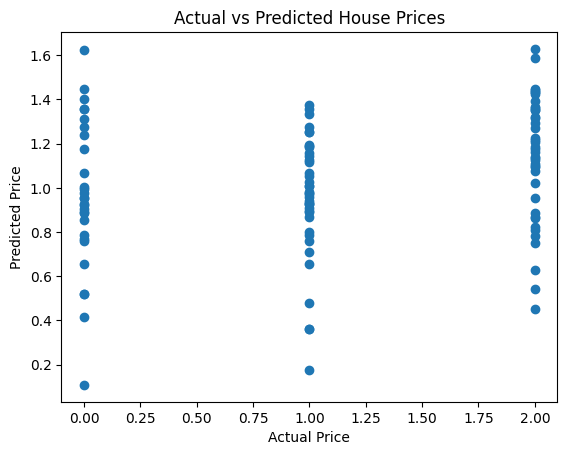

In [10]:
plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted House Prices"
)

plt.show()